<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Bryan Cabezas
- Nombre de alumno 2: Gonzalo Sobarzo


### **Link de repositorio de GitHub:** `https://github.com/BAFCS/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [2]:
import pandas as pd

df = pd.read_csv("Precios Casas RM.csv")

In [3]:
import missingno as msno
import plotly.express as px
from IPython.display import Markdown, display
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown("# Analisis columnas"))
    display(Markdown("## Descripcion variables"))
    display(df.describe())
    for col in df.columns:
        serie = df[col].copy()

        profile = pd.Series(dtype="object")
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}", nbins=48)

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

        else:
            count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f"## {serie.name} Profile"))
        display(profile)
        fig.show()

    display(Markdown("# Analisis de nulos"))
    display(Markdown("## Nulos por columna"))
    display(df.isna().sum())
    display(Markdown("## Visualizacion de nulos"))
    msno.matrix(df)
    display(Markdown("## Correlacion de nulidad"))
    msno.heatmap(df)

# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62364 bytes
dtype: object

...

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

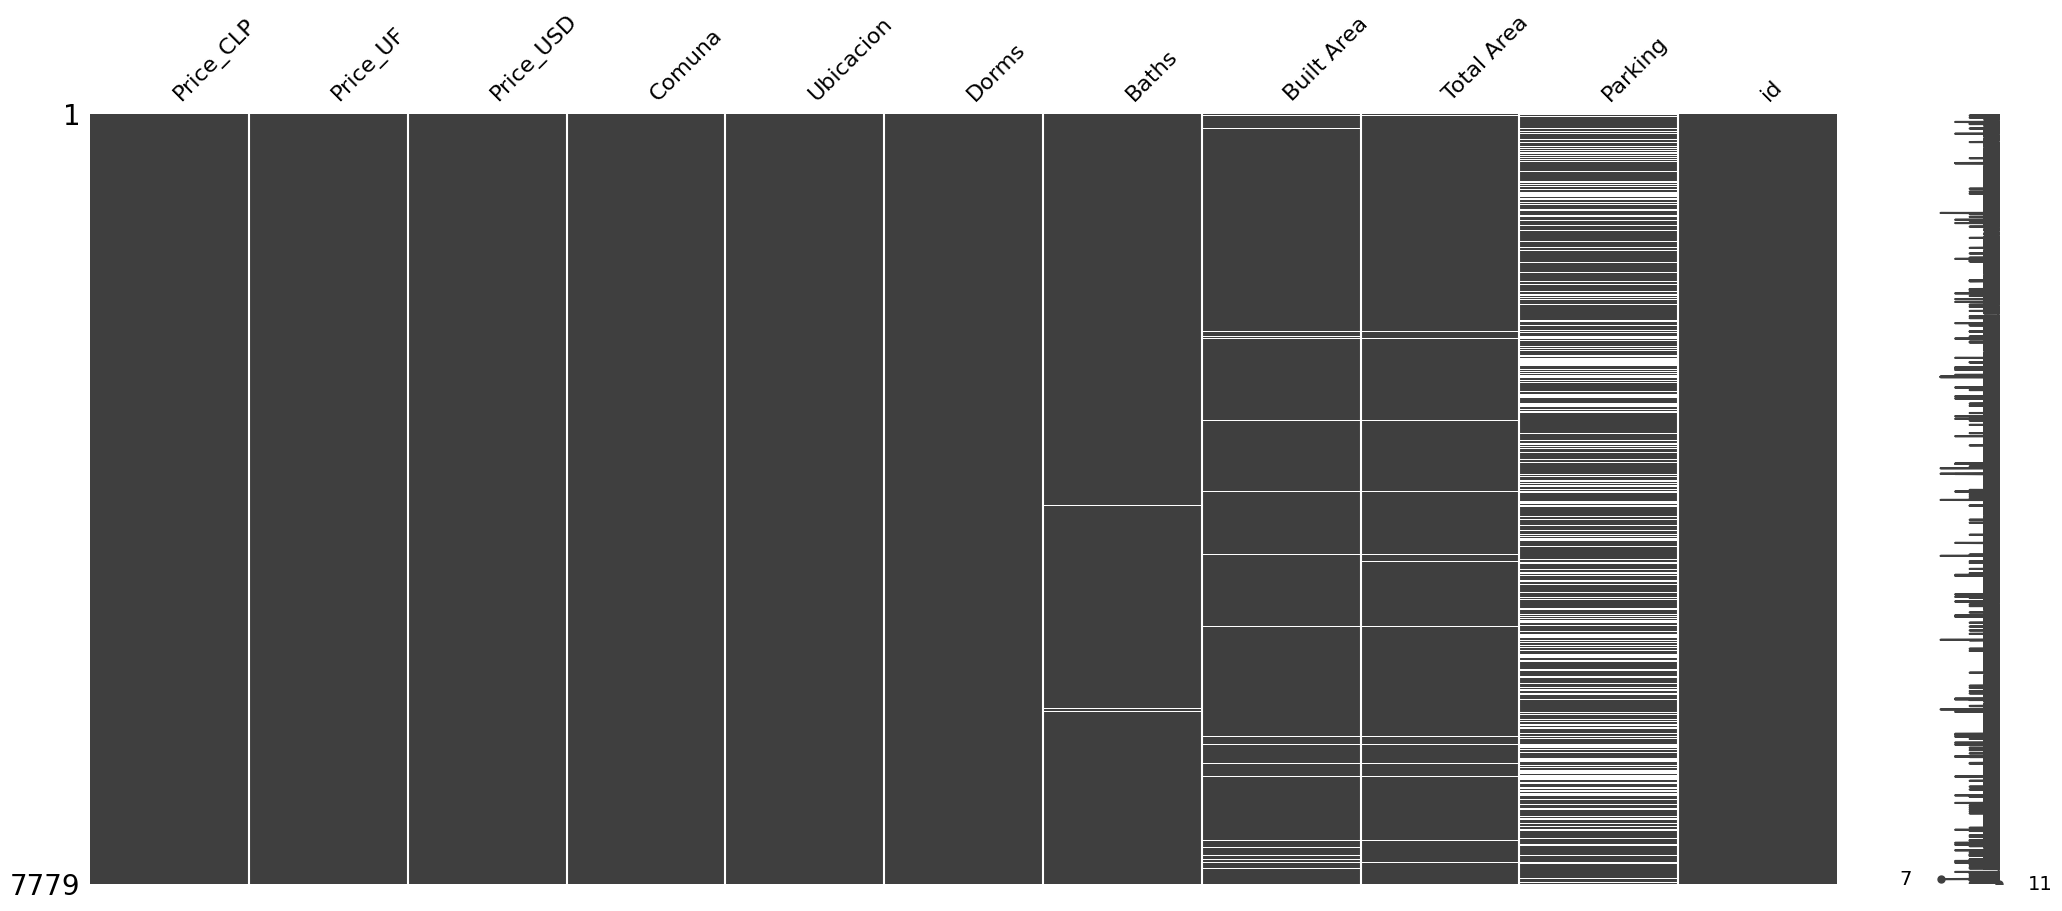

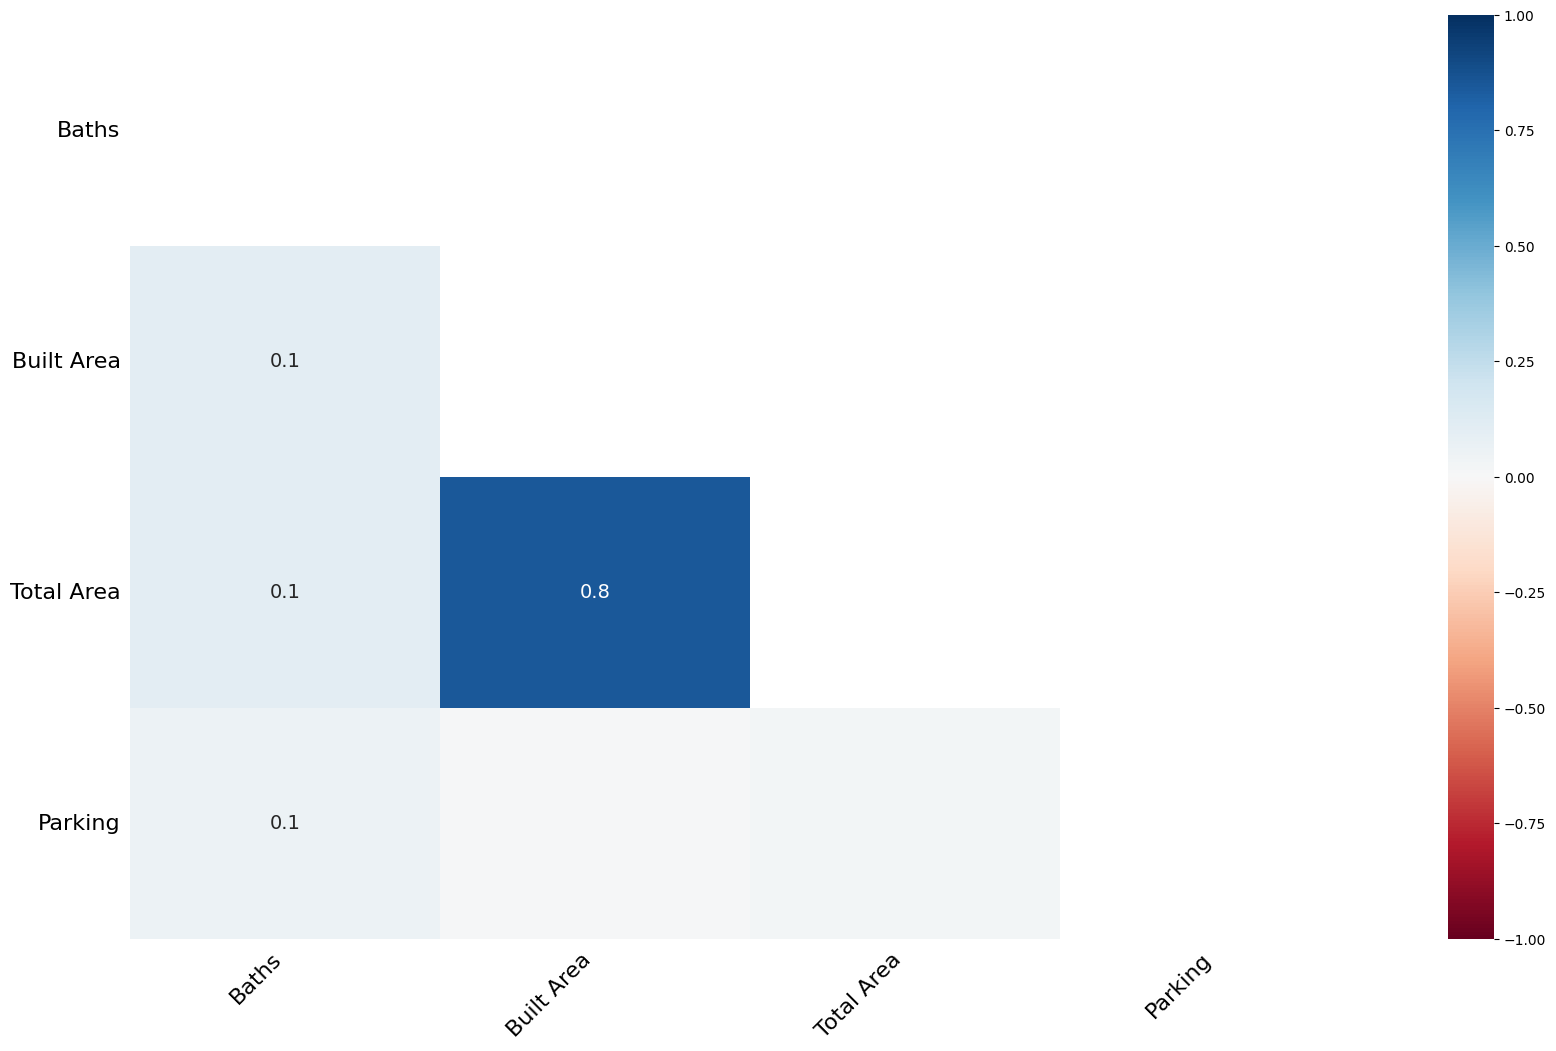

In [4]:
# Inserte acá su código
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

In [5]:
df

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397
...,...,...,...,...,...,...,...,...,...,...,...
7774,2491300000,70000,3102491,LasCondes,CalleSanJosédeLaSierra,5,5.0,600.0,1800.0,5.0,4708915
7775,242012000,6800,301385,Peñalolén,PasajeMarNegro,4,2.0,124.0,200.0,1.0,6641660
7776,3736950000,105000,4653736,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7.0,460.0,4925.0,8.0,6032811
7777,569440000,16000,709141,LaPintana,LosCipreses/LosDuraznos,4,2.0,311.0,2011.0,1.0,5314376


In [6]:
df[df["Baths"].isna()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
283,491142000,13800,611634,Colina,Chicureo-colina,4,NaN,270.0,4500.0,NaN,12315843
498,160000000,4496,199253,Macul,RodrigodeAraya,5,NaN,150.0,171.0,NaN,12268434
784,2135400000,60000,2659278,SanJosédeMaipo,Casamaipo,14,NaN,60000.0,60000.0,NaN,12196441
804,1352420000,38000,1684209,LasCondes,Altolascondes-padrehurtadonorte-lasverbenas.-m...,4,NaN,184.0,403.0,NaN,12190684
898,195000000,5479,242839,Santiago,SepúlvedaLeyton/Exposición,2,NaN,68.0,445.0,2.0,12155977
...,...,...,...,...,...,...,...,...,...,...,...
7242,638840500,17950,795567,LoBarnechea,Sectorpieandino,2,NaN,226.0,229.0,NaN,5714656
7294,133462500,3750,166205,LaCisterna,Elparrón,4,NaN,70.0,184.0,2.0,11283236
7334,80000000,2248,99626,LaGranja,Tongoy,2,NaN,NaN,156.0,3.0,11177826
7394,109900000,3088,136862,Maipú,Hermosacasaenbarriolasrosas,3,NaN,56.0,163.0,3.0,11009122


In [7]:
df[df["Parking"].isna()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
5,94000000,2641,117061,EstaciónCentral,Avenida5deAbril,2,1.0,72.0,131.0,NaN,7586371
14,199000000,5591,247821,Santiago,Cuevas,7,3.0,162.0,185.0,NaN,12155606
24,75000000,2107,93400,Quilicura,Riocachapoal,2,2.0,70.0,78.0,NaN,11426067
25,50000000,1405,62267,PuenteAlto,CerroParedones,3,1.0,31.0,73.0,NaN,11988681
36,225000000,6322,280199,Santiago,FranciscoPizarro2041,7,2.0,NaN,572.0,NaN,11903993
...,...,...,...,...,...,...,...,...,...,...,...
7728,280000000,7867,348692,SanJoaquín,SierraBella,4,NaN,NaN,NaN,NaN,3891570
7734,260000000,7305,323786,Paine,Paine,4,2.0,NaN,5100.0,NaN,6182159
7750,85000000,2388,105853,EstaciónCentral,AvenidaPedroAguirreCerda,3,1.0,53.0,55.0,NaN,8505694
7763,250000000,7024,311333,PuenteAlto,manuelrodriguez,4,2.0,196.0,750.0,NaN,7650477


In [8]:
df[df["Parking"] == 1269]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
253,925340000,26000,1152354,Ñuñoa,Hernancortes//pedrodevaldivia,11,4.0,567.0,702.0,1269.0,9275128


In [9]:
df.sort_values(by="Parking", ascending=False)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
253,925340000,26000,1152354,Ñuñoa,Hernancortes//pedrodevaldivia,11,4.0,567.0,702.0,1269.0,9275128
1495,209981000,5900,261496,EstaciónCentral,GeneralVelásquez,3,2.0,150.0,150.0,307.0,11978650
5146,770523500,21650,959556,Peñaflor,LasPalmeras,3,5.0,505.0,7332.0,60.0,9338146
2767,729595000,20500,908587,Colina,LosIngleses,9,7.0,415.0,5000.0,30.0,9635872
5309,320000000,8991,398506,Peñaflor,LosNogalesdeDonToribio,7,5.0,400.0,5000.0,30.0,9338062
...,...,...,...,...,...,...,...,...,...,...,...
7728,280000000,7867,348692,SanJoaquín,SierraBella,4,NaN,NaN,NaN,NaN,3891570
7734,260000000,7305,323786,Paine,Paine,4,2.0,NaN,5100.0,NaN,6182159
7750,85000000,2388,105853,EstaciónCentral,AvenidaPedroAguirreCerda,3,1.0,53.0,55.0,NaN,8505694
7763,250000000,7024,311333,PuenteAlto,manuelrodriguez,4,2.0,196.0,750.0,NaN,7650477


In [10]:
df.sort_values(by="Total Area", ascending=False)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
3304,800775000,22500,997229,LoBarnechea,Av.Ladehesa,5,3.0,250.0,678000.0,4.0,10028910
7214,130000000,3653,161893,Santiago,Av.LosCerrillos639,3,1.0,120000.0,300000.0,2.0,11362374
7262,159000000,4468,198007,Independencia,BrigadierCarlosGarrido1718,4,2.0,99.0,160000.0,1.0,11341949
2156,1099731000,30900,1369528,LasCondes,ColinadeGloria/GralBalnche,4,4.0,327.0,94929.0,3.0,9793534
2504,470000000,13206,585305,Tiltil,LasBateas,4,4.0,290.0,75000.0,NaN,4901365
...,...,...,...,...,...,...,...,...,...,...,...
7736,140000000,3934,174346,LaFlorida,LasCarmelitas,4,1.0,NaN,NaN,1.0,6943903
7737,145000000,4074,180573,PuenteAlto,Pieandino,3,2.0,NaN,NaN,1.0,6791067
7742,141000000,3962,175592,LaFlorida,CerroCaracol,3,3.0,NaN,NaN,2.0,7998394
7770,249130000,7000,310249,Santiago,Antilhue,3,3.0,NaN,NaN,2.0,6981371


In [11]:
df.sort_values(by="Built Area", ascending=False)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
7214,130000000,3653,161893,Santiago,Av.LosCerrillos639,3,1.0,120000.0,300000.0,2.0,11362374
784,2135400000,60000,2659278,SanJosédeMaipo,Casamaipo,14,NaN,60000.0,60000.0,NaN,12196441
5874,889750000,25000,1108032,Colina,lasbrisasdechicureo,4,4.0,31972.0,2892.0,6.0,11089439
2248,925340000,26000,1152354,LoBarnechea,Caminodelabrisa,5,4.0,18917.0,11927.0,2.0,11347739
2773,925304410,25999,1152309,Talagante,LonquenSurParadero/,6,3.0,17525.0,1800.0,5.0,7658745
...,...,...,...,...,...,...,...,...,...,...,...
7748,79579240,2236,99102,PuenteAlto,ClaudioArrau,2,1.0,NaN,76.0,2.0,8562578
7752,265536990,7461,330681,PuenteAlto,CondominioJardinesdeLasVizcachas,4,3.0,NaN,240.0,3.0,7740110
7755,160155000,4500,199446,Lampa,Batuco,3,3.0,NaN,500.0,2.0,8176463
7770,249130000,7000,310249,Santiago,Antilhue,3,3.0,NaN,NaN,2.0,6981371


In [12]:
df.sort_values(by="Baths", ascending=False)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
5838,1850680000,52000,2304707,Santiago,Hotel,25,29.0,1200.0,500.0,6.0,5345651
5561,234894000,6600,292521,Colina,Casaenventaenayresdechicureo,3,21.0,94.0,345.0,2.0,11129230
4911,658415000,18500,819944,Santiago,AremioGutierrez/PedroLagos,15,15.0,272.0,390.0,NaN,9086158
5153,587235000,16500,731301,Santiago,Santiago,17,15.0,350.0,350.0,NaN,9050315
5516,658415000,18500,819944,Santiago,SierraBella/PedroLagos,17,15.0,293.0,350.0,NaN,6022149
...,...,...,...,...,...,...,...,...,...,...,...
7242,638840500,17950,795567,LoBarnechea,Sectorpieandino,2,NaN,226.0,229.0,NaN,5714656
7294,133462500,3750,166205,LaCisterna,Elparrón,4,NaN,70.0,184.0,2.0,11283236
7334,80000000,2248,99626,LaGranja,Tongoy,2,NaN,NaN,156.0,3.0,11177826
7394,109900000,3088,136862,Maipú,Hermosacasaenbarriolasrosas,3,NaN,56.0,163.0,3.0,11009122


In [13]:
df[df["Built Area"].isna()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
15,79000000,2220,98381,PuenteAlto,PasajeLagoBertrand,2,1.0,NaN,NaN,2.0,12149041
29,75000000,2107,93400,PuenteAlto,TocornalExPedroDuarte,3,1.0,NaN,87.0,1.0,6775287
30,85000000,2388,105853,PuenteAlto,Maullín,5,2.0,NaN,105.0,1.0,6776151
33,290000000,8148,361146,PuenteAlto,Noruega/Eyzaguirre,5,3.0,NaN,286.0,2.0,8298437
36,225000000,6322,280199,Santiago,FranciscoPizarro2041,7,2.0,NaN,572.0,NaN,11903993
...,...,...,...,...,...,...,...,...,...,...,...
7748,79579240,2236,99102,PuenteAlto,ClaudioArrau,2,1.0,NaN,76.0,2.0,8562578
7752,265536990,7461,330681,PuenteAlto,CondominioJardinesdeLasVizcachas,4,3.0,NaN,240.0,3.0,7740110
7755,160155000,4500,199446,Lampa,Batuco,3,3.0,NaN,500.0,2.0,8176463
7770,249130000,7000,310249,Santiago,Antilhue,3,3.0,NaN,NaN,2.0,6981371


In [14]:
df[df["Total Area"].isna()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
15,79000000,2220,98381,PuenteAlto,PasajeLagoBertrand,2,1.0,NaN,NaN,2.0,12149041
80,170000000,4777,211706,Conchalí,Nilahue,6,2.0,NaN,NaN,NaN,11608988
97,139000000,3906,173101,Recoleta,AvenidaMéxico,6,2.0,140.0,NaN,NaN,6716881
101,80000000,2248,99626,SanBernardo,Villaalameda,4,3.0,NaN,NaN,2.0,11449618
198,60000000,1686,74720,PuenteAlto,VillaDuraznal,3,1.0,NaN,NaN,1.0,9809866
...,...,...,...,...,...,...,...,...,...,...,...
7736,140000000,3934,174346,LaFlorida,LasCarmelitas,4,1.0,NaN,NaN,1.0,6943903
7737,145000000,4074,180573,PuenteAlto,Pieandino,3,2.0,NaN,NaN,1.0,6791067
7742,141000000,3962,175592,LaFlorida,CerroCaracol,3,3.0,NaN,NaN,2.0,7998394
7770,249130000,7000,310249,Santiago,Antilhue,3,3.0,NaN,NaN,2.0,6981371


`Escriba sus respuestas acá:`
1. La variable objetivo price presenta una distribución sesgada a la derecha, caracterizada por una alta densidad de casas en los rangos inferiores y una cola extensa hacia valores altos. Esto se confirma con un Skew de 2.80 que confirma una asimetría positiva donde la media es desplazada por valores extremos, y una Kurtosis de 14.321 indicando colas pesadas y una alta frecuencia de outliers. El rango de precios oscila entre 2.085 - 5.516.450.000, junto con una desviación estándar de 386.880.986, evidenciando una dispersión masiva de los datos, indicando que existen casas con un valor muy bajo, pero algunas con un precio exageradamente alto.  Asimismo en el boxplot se observa datos atipicos representados por los valores altos, que superan el tercer cuartil del 75% de las casas que presentan un precio igual o menor a 491.142.000. Finalmente, se muestra que la variable no presenta datos faltantes, zeros ni negativos. Aún asi, se observan 6.680 valores duplicados, lo cual es normal al ser precios inmobilarios.

2. La variable categórica Comuna es relevante para el precio de la vivienda, ya que en ciertas comunas el precio del terreno es mayor que en otras, ya sea por la seguridad, infraestructura, movilidad, entre otros. Se observa que se presentan más casas en la comuna de Puente alto. Asimismo, presenta 51 valores únicos para 7.779 observaciones, lo cual es una cardinaldiad manejable para técncias como One-Hot Encondig o Target Encoding, permitiendo al modelo generalizar patrones por sectores y siendo una **buena variable a agregar**. Por otro lado, la variable Ubicación entrega una dirección más específica de la casa, presentando 6.620 valores únicos, demostrando que cada casa tiene una ubicación distinta, lo cual **no sería una buena variable para el modelo**, ya que generaria un gran cantidad de columnas al aplicar One-Hot encoding, generando que el modelo pueda sufrir sobreajuste, aprendiendo el modelo cada ubicación, en vez de tendencias generales, posiblemente trayendo la "maldición de la dimensionalidad".

3. Los nulos de la variable Bath representan datos que **no está disponible**, debido que una casa no puede no tener baños, indicando un error en el llenado del aviso o omisión. Los valores nulos de la Parking, se refiere a **representa un valor determinado**, es decir, son hogares que no presentan parking, por lo cual deberia ser imputado por 0 al ser númerica la variable. La variable Built Area presentan valores entre 1.0 y 120.000, que indica el área construido, al ser únicamente casas y no terrenos, significa que los valores nulos representan **no está disponible**, lo cual lo confirma, ya que existen filas que si existen baños y dormitorios pero NaN en Built Area. Finalmente, la variable Total Area también presentan valores nulos representados por **no está disponible**, ya que toda propiedad tiene una superficie total de terreno. Si el dato es nulo, es porque no se extrajo correctamente o no se especificó.


4. **No, la variable id no se debería ocupar**, ya que no representa un patrón de la vivienda que el modelo pueda aprender, sino únicamente es un valor único (alta cardinalidad) que representa cada valor agregado al conjunto de datos y no esta directamente relacionado con las caracteristicas o precio de la vivienda. Agregarla podría generar overfitting al aprender cada valor.

5. **Sí, se observan valores atípicos principalmente en la variable objetivo `Price_CLP`**. Los valores extremadamente altos superan significativamente el rango típico, alcanzando un máximo de 5,516,450,000 CLP que excede el tercer cuartil (491,142,000) por un margen considerable, siendo claramente visibles en el boxplot como puntos aislados en la cola derecha de la distribución. Esta presencia de outliers se confirma estadísticamente con el Skew de 2.80 (asimetría positiva pronunciada) y la Kurtosis de 14.321 (indicando colas pesadas) como ya se había dicho con anterioridad, donde la desviación estándar de 386,880,986 es muy superior a la mediana, evidenciando desviaciones extremas del centro de la distribución. Estos valores atípicos corresponden probablemente a propiedades de lujo ubicadas en comunas de alto valor como Las Condes o Providencia con características excepcionales. Aunque estos outliers podrían afectar el entrenamiento del modelo, especialmente en modelos lineales, decidimos mantenerlos porque representan casas reales en el mercado inmobiliario chileno. Por otro lado, observamos que la variable **Parking** presenta un outlier extremo, con un valor máximo de 1269 estacionamientos, lo cual es imposible para una casa de 702.0 metros cuadrados. Un valor atipico similar que se repite ocurre en la variable **Total Area**, donde se observa una casa con una superficie de 678.000 m^2, con un **Built Area** de 120.000 m^2 en zona urbana, lo cual es bastante inusual, ya que una construcción de ese tamaño superaria el tamaño de grandes centros comerciales. Las variables **Baths** y **Dorms** también presentan valores atípicos, pero no son extremandamente altos y puede ocurrir que en casas muy grandes tengan dicha capacidad, sobretodo dado que en ubicación dice Hotel, por lo cual probablemente sea una casa que se utilicé para ese fin.

### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [15]:
from sklearn.model_selection import train_test_split


def preparacion_de_datos(random_state=42):
    # 1. Cargar dataset
    df = pd.read_csv("Precios Casas RM.csv")

    # 2. Eliminar duplicados exactos
    # Según el EDA, hay 6,680 duplicados, se eliminarán manteniendo el primer registro
    df = df.drop_duplicates(keep="first")

    # 3. Eliminar filas nulas en columnas que representan "datos no disponibles"
    # Según el EDA:
    # - Baths: nulos = datos no disponible → eliminar
    # - Built Area: nulos = datos no disponible → eliminar
    # - Total Area: nulos = datos no disponible → eliminar
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])

    # 4. Imputar Parking con 0 (representa que no tiene parking)
    df["Parking"] = df["Parking"].fillna(0)

    # 5. Eliminan datos atipicos demasiados extremos
    df = df[df["Parking"] < 60]
    df = df[df["Built Area"] < 60000]
    df = df[df["Total Area"] < 160000]

    # 5. Eliminar columnas no útiles
    # - id: alta cardinalidad, solo identifica cada registro
    # - Ubicacion: 6,620 valores únicos causaría sobreajuste
    # - Price_UF y Price_USD: redundantes con Price_CLP
    df = df.drop(columns=["id", "Ubicacion", "Price_UF", "Price_USD"])

    # 6. Separar target y features
    X = df.drop(columns=["Price_CLP"])
    y = df["Price_CLP"]

    # 7. Train/test split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    return X_train, X_test, y_train, y_test

In [16]:
X_train, X_test, y_train, y_test = preparacion_de_datos()

print(f"Tamaño conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto de test: {X_test.shape}")
print(f"\nRatio train/test: {X_train.shape[0] / X_test.shape[0]:.2f}:1")
print(f"Porcentaje test: {X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100:.1f}%")
print(f"\nColumnas en X_train: {X_train.columns.tolist()}")

Tamaño conjunto de entrenamiento: (5968, 6)
Tamaño conjunto de test: (1492, 6)

Ratio train/test: 4.00:1
Porcentaje test: 20.0%

Columnas en X_train: ['Comuna', 'Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking']


Justificar su preparación de datos.

**¿Qué columnas usó para eliminar nulos y por qué?**

Se eliminaron las filas nulas en las columnas **Baths**, **Built Area** y **Total Area** porque según el análisis EDA, estos nulos representan "datos no disponibles" (información faltante en la recolección). Una vivienda siempre tiene estos atributos, así que registros sin esta información no son confiables para entrenar el modelo.

Para **Parking**, por el contrario, imputé los nulos con 0 porque representan viviendas que simplemente no tienen estacionamiento (es un valor determinado), no datos faltantes.

Se decidio aplicar una limpieza de los datos atípicos más extremos en la variable **Parking**, **Total Area** y **Built Area**, ya que poseian escalas de dimensiones de grandes centros comerciales o infraestructuras indutriales. Dado que la documentación advierte sobre errores de escala, se determinó que estos registros constituyen ruido técnico.

Se eliminaron las columnas **id**, **Ubicacion**, **Price_UF** y **Price_USD** porque:
- **id**: Alta cardinalidad, solo identifica cada registro sin patrón predictivo
- **Ubicacion**: 6,620 valores únicos (una casi para cada casa) causaría sobreajuste
- **Price_UF** y **Price_USD**: Redundantes con **Price_CLP** (mismo precio en diferentes unidades)

**¿Qué proporción de los datos usó para test y por qué?**

Se utilizó un split 80% (train) - 20% (test) con `train_test_split`. Esta proporción es estándar en machine learning porque:
- **80% train**: Proporciona suficientes datos para que el modelo aprenda patrones generales
- **20% test**: Tamaño adecuado (~1,500 muestras) para evaluar la generalización sin perder poder predictivo

La semilla `random_state=42` garantiza reproducibilidad de resultados.


### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Definir columnas numéricas y categóricas
numeric_cols = ["Dorms", "Baths", "Built Area", "Total Area", "Parking"]
categorical_cols = ["Comuna"]

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

print("ColumnTransformer creado exitosamente")
print(f"Columnas numéricas: {numeric_cols}")
print(f"Columnas categóricas: {categorical_cols}")

ColumnTransformer creado exitosamente
Columnas numéricas: ['Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking']
Columnas categóricas: ['Comuna']


Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?
- ¿Por qué escaló los features de esta forma?
- ¿Qué valor(es) usó para imputación y por qué?

`Escriba sus respuestas acá:`

**¿Qué columnas eliminó y por qué?**

No se eliminó ninguna columna en el preprocesamiento porque ya fueron eliminadas en la función `preparacion_de_datos`. En esta fase se utilizan todas las columnas disponibles (Dorms, Baths, Built Area, Total Area, Parking, Comuna) ya que son todas predictivas. Se preservó específicamente la variable `Comuna` como requiere el laboratorio, la cual será transformada mediante One-Hot Encoding.

**¿Por qué escaló los features de esta forma?**

Se aplicó **StandardScaler** a las variables numéricas porque:
- Los modelos de regresión lineal y sus variantes (Ridge, Lasso, ElasticNet) son sensibles a la escala de los features
- StandardScaler normaliza cada variable a media 0 y desviación estándar 1: $(X - \mu) / \sigma$
- Esto es especialmente importante porque nuestras variables tienen rangos muy diferentes:
  - Dorms, Baths, Parking: rango [0-10]
  - Built Area, Total Area: rango [1-120,000]
- Sin escalamiento, las variables con mayor rango dominarían el modelo y los coeficientes de regresión serían sesgados

**¿Qué valor(es) usó para imputación y por qué?**

No se requirió imputación adicional en esta fase porque:
- Los nulos ya fueron manejados en `preparacion_de_datos`: eliminando filas con Baths, Built Area, Total Area nulos (datos no disponibles)
- Parking nulos ya fueron imputados con 0 (representa sin estacionamiento)
- Por lo tanto, el ColumnTransformer recibe datos sin valores nulos

El **OneHotEncoder** utiliza `drop='first'` para evitar multicolinealidad (la trampa de las variables dummy), reduciendo el número de columnas categóricas creadas en 1.


### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [18]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Se elige Ridge como modelo base por su capacidad de manejar multicolinealidad y evitar sobreajuste, lo cual es relevante dado el número de características después de OneHotEncoding.
pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=1.0, random_state=42))])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    metrics = {
        "RMSE Train": root_mean_squared_error(y_train, y_train_pred),
        "RMSE Test": root_mean_squared_error(y_test, y_test_pred),
        "MAE Train": mean_absolute_error(y_train, y_train_pred),
        "MAE Test": mean_absolute_error(y_test, y_test_pred),
        "R2 Train": r2_score(y_train, y_train_pred),
        "R2 Test": r2_score(y_test, y_test_pred),
    }

    return metrics

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [29]:
def complete_pipeline_v1():
    # 1. Preparación de datos
    X_train, X_test, y_train, y_test = preparacion_de_datos()

    # 2. Preprocesamiento y modelado
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge(alpha=1.0, random_state=42))])

    pipeline.fit(X_train, y_train)

    # 3. Evaluación del modelo
    metrics = evaluate_model(pipeline, X_train, X_test, y_train, y_test)

    return metrics, pipeline

In [32]:
# Ejecutar la función
metrics, pipe_v1 = complete_pipeline_v1()
print("Métricas del modelo:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Métricas del modelo:
RMSE Train: 224010112.4942
RMSE Test: 219644700.2961
MAE Train: 122048559.8895
MAE Test: 121216777.0829
R2 Train: 0.6724
R2 Test: 0.6617


3. Responder las siguientes preguntas (0.15 ptos c/u)

`Escriba sus respuestas acá:`

**¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)**

El desempeño del modelo debe evaluarse considerando las tres métricas de forma integrada. El **RMSE (Root Mean Squared Error)** indica el error promedio en pesos chilenos, penalizando fuertemente los errores grandes. El modelo obtuvo un RMSE de 224.010.112 en Train y 219.644.700 en Test, lo que indica que el sistema se equiva en promedio en unos 219 millones de pesos respecto al valor real. Asimismo, al ser considerablemente más alto que el MAE, confirma que el modelo presenta dificultades para ajustarse a los precios extremos o propiedades de lujo (outliers), al desviarse y fallando críticamente en la parte alta del mercado. El **MAE (Mean Absolute Error)** proporciona una interpretación más directa: representa el error promedio absoluto en pesos sin ponderar los outliers. Aquí se obtuvo un MAE de 122.048.560 en Train y 121.216.777 en Test, indicando que la predicción en promedio suele errar por aprox. 121 millones de pesos en una vivienda común. Este error es bastante alto, mostrando que arrastra más de 120 millones en una casa de precio promedio, dejando al modelo fuera de competencia para una tasación comercial precisa. El **R² (Coeficiente de Determinación)** explica qué porcentaje de la variabilidad de precios es capturada por el modelo (0-1, siendo 1 perfecto). Un R² de 0.6724 en Train y 0.6617 en Test, significa que la recta de la regresión logra de manera aceptable el 66.17% de la variabilidad de los precios inmobilarios mediante las caracteristicas, lo cual es un valor aceptable.

Finalmente, la contradicción significa que el modelo sí entendió la tendencia general del mercado, dando un buen valor en R². Sin embargo, la dispersión y los precios del dataset son tan masivos, que aunque el modelo acierte en la dirección correcta, la distancia en dinero real sigue siendo enorme.

**¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?**

Optimizar **RMSE** prioriza reducir errores grandes, siendo útil cuando los errores extremos son costosos (penaliza outliers). Optimizar **MAE** es más robusto ante outliers y proporciona interpretabilidad directa en unidades de dinero, siendo preferible cuando se desea estabilidad ante precios extremos como los identificados en el EDA. Optimizar **R²** busca maximizar la explicación de variabilidad general, importante para entender patrones de mercado pero potencialmente ignorando errores consistentes. En el contexto inmobiliario, **MAE es probablemente la métrica más adecuada** porque los analistas necesitan entender el error promedio en pesos sin que las propiedades de lujo sesgen exageradamente la evaluación.

**¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error**

Los factores principales incluyen: **(1) Limitaciones de features**: El modelo solo utiliza 6 variables (Dorms, Baths, Built Area, Total Area, Parking, Comuna), pero el precio de viviendas depende de muchas más características no capturadas (antigüedad, materiales, orientación, vista, cercanía a transporte, seguridad barrial). **(2) Distribución sesgada de precios**: El EDA reveló asimetría positiva (Skew=2.80) con outliers extremos; los modelos lineales asumen relaciones lineales que pueden no capturar bien la no-linearidad en rangos de precios muy distintos. **(3) Heterogeneidad del mercado**: Comunas diferentes pueden tener dinámicas de precios completamente distintas; una simple categoría Comuna no captura complejidades socioeconómicas. **(4) Duplicados y datos faltantes**: Aunque se eliminaron duplicados, pueden existir precios erróneos o registros atípicos no identificados. **(5) Multicolinealidad**: Built Area y Total Area pueden estar altamente correlacionadas, reduciendo independencia de predictores.

**Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique**

Sobreajuste ocurre cuando el modelo memoriza patrones de entrenamiento en lugar de generalizar. Si las métricas de test son significativamente peores que train (ej: R² train > 0.90 pero R² test < 0.70), indica sobreajuste. Se espera cierta degradación en test (es normal), pero si es muy pronunciada, sugiere que el modelo no generalizó bien. Al analizar los resultados, se observa que el modelo no presenta sobreajuste, ya que las métricas entre Train y Test son prácticamente idénticas, presentando una diferencia en R² de apenas un 1.07%, y los errores globales (MAE y RMSE) se mantuvieron estables o disminuyeron muy ligeramente. Esto demuestra que la exclusión de varaibles con excesiva cardinalidad como Ubicación, y la limpieza manual de dimensiones imposibles, impidieron que el modelo cayera en overfitting, demostrando que el modelo es deficviente en su precisión en pesos, pero honesto al generalizar.


## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [22]:
def preparacion_de_datos_2(random_state=42):
    df = pd.read_csv("Precios Casas RM.csv")
    df_comunas = pd.read_excel("ingresos_por_comuna_2024.xlsx")

    # Normalizar nombres en caso de haber mayusculas y minusculas
    # Limpiar espacios y pasar a mayúsculas
    df["Comuna"] = df["Comuna"].str.strip().str.upper()
    df_comunas["Nombre comuna"] = df_comunas["Nombre comuna"].str.strip().str.upper()

    # Se hace un left para no perder registros originales
    df = df.merge(
        df_comunas[["Nombre comuna", "Porcentaje de personas en situacion de pobreza de ingresos 2024"]],
        left_on="Comuna",
        right_on="Nombre comuna",
        how="left",
    )

    df = df.rename(columns={"Porcentaje de personas en situacion de pobreza de ingresos 2024": "poverty_rate"})
    # 2. Eliminar duplicados exactos
    # Según el EDA, hay 6,680 duplicados, se eliminarán manteniendo el primer registro
    df = df.drop_duplicates(keep="first")

    # 3. Eliminar filas nulas en columnas que representan "datos no disponibles"
    # Según el EDA:
    # - Baths: nulos = datos no disponible → eliminar
    # - Built Area: nulos = datos no disponible → eliminar
    # - Total Area: nulos = datos no disponible → eliminar
    # - poverty_rate: nulos = datos no disponible → eliminar
    df = df.dropna(subset=["Baths", "Built Area", "Total Area", "poverty_rate"])

    # 4. Imputar Parking con 0 (representa que no tiene parking)
    df["Parking"] = df["Parking"].fillna(0)

    # 5. Eliminan datos atipicos demasiados extremos
    df = df[df["Parking"] < 60]  # Filtro conservador
    df = df[df["Built Area"] < 60000]
    df = df[df["Total Area"] < 160000]

    # 5. Eliminar columnas no útiles
    # - id: alta cardinalidad, solo identifica cada registro
    # - Ubicacion: 6,620 valores únicos causaría sobreajuste
    # - Price_UF y Price_USD: redundantes con Price_CLP
    # - Nombre comuna es redundante con Comunas
    df = df.drop(columns=["id", "Ubicacion", "Price_UF", "Price_USD", "Nombre comuna"])

    # 6. Separar target y features
    X = df.drop(columns=["Price_CLP"])
    y = df["Price_CLP"]

    # 7. Train/test split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    return X_train, X_test, y_train, y_test

In [23]:
X_train, X_test, y_train, y_test = preparacion_de_datos_2()

print(f"Tamaño conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto de test: {X_test.shape}")
print(f"\nRatio train/test: {X_train.shape[0] / X_test.shape[0]:.2f}:1")
print(f"Porcentaje test: {X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100:.1f}%")
print(f"\nColumnas en X_train: {X_train.columns.tolist()}")

Tamaño conjunto de entrenamiento: (5968, 7)
Tamaño conjunto de test: (1492, 7)

Ratio train/test: 4.00:1
Porcentaje test: 20.0%

Columnas en X_train: ['Comuna', 'Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking', 'poverty_rate']


### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [24]:
# Ingresar su código aquí
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

# Definir columnas numéricas y categóricas
numeric_cols = ["Dorms", "Baths", "Built Area", "Total Area", "Parking", "poverty_rate"]
categorical_cols = ["Comuna"]

# Crear el ColumnTransformer
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", TargetEncoder(target_type="continuous"), categorical_cols),
    ]
)

print("ColumnTransformer creado exitosamente")
print(f"Columnas numéricas: {numeric_cols}")
print(f"Columnas categóricas: {categorical_cols}")

ColumnTransformer creado exitosamente
Columnas numéricas: ['Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking', 'poverty_rate']
Columnas categóricas: ['Comuna']


In [33]:
def complete_pipeline_v2():
    # 1. Preparación de datos
    X_train, X_test, y_train, y_test = preparacion_de_datos_2()

    # 2. Preprocesamiento y modelado
    pipeline = Pipeline([("preprocessor", preprocessor_v2), ("model", Ridge(alpha=1.0, random_state=42))])

    pipeline.fit(X_train, y_train)

    # 3. Evaluación del modelo
    metrics = evaluate_model(pipeline, X_train, X_test, y_train, y_test)

    return metrics, pipeline

In [34]:
# Ejecutar la función
metrics, pipe_v2 = complete_pipeline_v2()
print("Métricas del modelo:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Métricas del modelo:
RMSE Train: 226687035.7531
RMSE Test: 223112321.9322
MAE Train: 125342639.7295
MAE Test: 124601631.8320
R2 Train: 0.6645
R2 Test: 0.6509


/Users/bryan/Desktop/MDS/segundo semestre/Laboratorio de ciencia de datos/Repo/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.436360826822805e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [35]:
# Ingresar su código aquí
metrics_v1, pipe_v1 = complete_pipeline_v1()
metrics_v2, pipe_v2 = complete_pipeline_v2()

# DataFrame para comparar los resultados
df_comparacion = pd.DataFrame(
    {
        "Métrica": ["R2 Train", "R2 Test", "RMSE Train", "RMSE Test", "MAE Train", "MAE Test"],
        "Pipeline v1": [
            metrics_v1["R2 Train"],
            metrics_v1["R2 Test"],
            metrics_v1["RMSE Train"],
            metrics_v1["RMSE Test"],
            metrics_v1["MAE Train"],
            metrics_v1["MAE Test"],
        ],
        "Pipeline v2": [
            metrics_v2["R2 Train"],
            metrics_v2["R2 Test"],
            metrics_v2["RMSE Train"],
            metrics_v2["RMSE Test"],
            metrics_v2["MAE Train"],
            metrics_v2["MAE Test"],
        ],
    }
)

print("\n--- TABLA COMPARATIVA DE RESULTADOS ---")
print(df_comparacion.to_string(index=False))


--- TABLA COMPARATIVA DE RESULTADOS ---
   Métrica  Pipeline v1  Pipeline v2
  R2 Train 6.724233e-01 6.645714e-01
   R2 Test 6.616573e-01 6.507960e-01
RMSE Train 2.240101e+08 2.266789e+08
 RMSE Test 2.196447e+08 2.231423e+08
 MAE Train 1.220486e+08 1.253123e+08
  MAE Test 1.212168e+08 1.245900e+08


/Users/bryan/Desktop/MDS/segundo semestre/Laboratorio de ciencia de datos/Repo/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4279516783875265e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


`Escriba su respuesta acá:`

Según los resultados obtenidos, el Pipeline V1 presenta mayor R2 de prueba (66.17% vs 65.08%) y menores margenes de error tanto en MAE como RMSE (errando, en promedio, aprox. 3.3 millones de pesos menos por vivienda que la v2). Aún asi, el pipeline V2 es más liviano para ser implementado en producción al no presentar más de 50 columnas binarias de comuna, sino solo una columna numérica codificada, junto con mayor intepretabilidad socioeconomico con poverty_rate. Asimismo, un modelo no lineal, como Random Forest o XGBoost podria entregar mejor resultados, al aprovechar mejor los índices de pobreza sin la rigidez de una línea recta. Cabe mencionar, que ninguno de los 2 modelos presenta sobreajuste.

### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

`Escriba su respuesta acá:`

El modelo V1 obtuvo mejor resultado que la V2, debido que al aplicar One-Hot Encoding, permitió expandir la variable "Comuna" en más de 50 columnas binarias independientes, por lo que al entrenar el modelo Ridge, el algoritmo presentó más libertad matemática de asignarle coeficientes aislados a cada comuna. En cambio, el Pipeline V2 comprime toda la información en solo una columna numérica mediante TargetEncoder. Además, al agregar la variable poverty_rate, el modelo Ridge tuvo que buscar una línea recta, obligando a buscar una relación líneal global entre la tasa de pobreza y el precio de la casa, pero al presentar variabilidad el mercado inmobiliario, presentando algunas casas con un precio alto en comunas con alta tasa de pobreza, la simplificación extrema le restó capacidad de ajuste al modelo v2, aumentando sus errores en peso. Otra razon por la cual es el modelo V2 presentó un peor rendimiento, fue posiblemente por la incorporación de la variable externa "poverty_rate" mediante el merge, ya que la pobreza por ingreso mide una realidad común general, pero no discrimina la micro-segmentación dentro de las comunas, es decir, existen condominios exclusivos colindantes en zonas vulnerables. Además, al aplicar el cruce de datos, se eliminaron registros cuyas comunas no coincidían tipográficamente con el dataset original, por lo cual podría haber perdido ejemplos valiosos para el modelo.

Respecto al sobreajuste, en general, al aumentar las dimensiones se eleva el riesgo de sobreajuste. Sin embargo, gracias a la regularización Ridge L2 del modelo y la limpieza anterior aplicada, se logro frenar el peligro de overfitting. Demostrando que la brecha entre Train y Test es muy baja, confirmando que el modelo V1 aprovechó su alta flexibilidad para predecir mejor sin llegar a sobreajustarse.

2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [36]:
# Escriba su código aquí
# Contar parámetros del pipeline V1 y V2
modelo_v1 = pipe_v1.named_steps["model"]
print(f"Cantidad de parámetros Modelo V1: {len(modelo_v1.coef_)}")

modelo_v2 = pipe_v2.named_steps["model"]
print(f"Cantidad de parámetros Modelo V2: {len(modelo_v2.coef_)}")

Cantidad de parámetros Modelo V1: 55
Cantidad de parámetros Modelo V2: 7


`Escriba su respuesta acá:`

Se observa que el modelo V1 presenta 55 parámetros, debido que al aplicar One-Hot Encoding, se agregaron nuevas variables según la cantidad de comunas que se presentabá. Asimismo, al agregar un modelo Ridge, se le asignó a cada variable un coeficiente, lo cual genera un modelo más complejo en comparación al modelo V2, donde se observa únicamente 7 parámetros. Esto se debe que al reemplazar One-hot Encoding por Target Encoding, este método reemplazó la columna categórica de comunas por una única variable numérica continua, la cual calcula la media del precio de las viviendas para cada comuna y la pondera con el promedio global del dataset. Al condensar toda la información geográfica en una sola métrica de impacto económico directo, el segundo pipeline logró reducir la cantidad de parámetros en un 87.3%, pasando de 55 coeficientes a solo 7 (incluyendo poverty_rate), generando un modelo más simple y compacto.

Tomando en cuenta esto, se puede indicar que el segundo pipeline demuestra una alta eficiencia bajo el principio de parsimonia, es decir buscar un modelo más simple. Como se mostró anteriormente, la capacidad explicativa del modelo del segundo pipeline V2 en el conjunto de prueba (R^2 Test) solo disminuyó en un 1.09% (cayendo de 0.6617 en V1 a 0.6508 en V2), mientras que el error MAE solo aumentó unos 3.3 millones de pesos, lo cual demuestra que el segundo modelo puede ser una opción más robusta para ser aplicado en producción. Aún asi, los resultados en general de ambos modelos no fueron precisos y presentan un error alto.
